# Tech Challenge — Fase 1 E-commerce Olist
## Relatório Executivo: Performance Comercial, Logística e Satisfação do Cliente

**Objetivo:** transformar os dados transacionais do Olist (2016–2018) em uma narrativa executiva sobre desempenho comercial, eficiência logística e satisfação do cliente, com recomendações acionáveis para investidores e acionistas.



# **1. Preparando o ambiente e importando os dados**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', 100)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)


In [4]:
BASE_URL = "https://raw.githubusercontent.com/Filipi-Cavalcante/tech-challenge-olist./refs/heads/main/data/"

customers  = pd.read_csv(BASE_URL + "olist_customers_dataset.csv")
orders     = pd.read_csv(BASE_URL + "olist_orders_dataset.csv", parse_dates=[
                "order_purchase_timestamp", "order_approved_at",
                "order_delivered_carrier_date", "order_delivered_customer_date",
                "order_estimated_delivery_date"])
items      = pd.read_csv(BASE_URL + "olist_order_items_dataset.csv", parse_dates=["shipping_limit_date"])
payments   = pd.read_csv(BASE_URL + "olist_order_payments_dataset.csv")
reviews    = pd.read_csv(BASE_URL + "olist_order_reviews_dataset.csv", parse_dates=[
                "review_creation_date", "review_answer_timestamp"])
products   = pd.read_csv(BASE_URL + "olist_products_dataset.csv")
sellers    = pd.read_csv(BASE_URL + "olist_sellers_dataset.csv")
cat_trans  = pd.read_csv(BASE_URL + "product_category_name_translation.csv")

tables = {"customers": customers, "orders": orders, "items": items, "payments": payments,
          "reviews": reviews, "products": products, "sellers": sellers, "cat_trans": cat_trans}

for name, df in tables.items():
    print(f"{name:12s} -> {df.shape[0]:>8,} linhas | {df.shape[1]:>2} colunas".replace(",", "."))




customers    ->   99.441 linhas |  5 colunas
orders       ->   99.441 linhas |  8 colunas
items        ->  112.650 linhas |  7 colunas
payments     ->  103.886 linhas |  5 colunas
reviews      ->   99.224 linhas |  7 colunas
products     ->   32.951 linhas |  9 colunas
sellers      ->    3.095 linhas |  4 colunas
cat_trans    ->       71 linhas |  2 colunas


## 2. Organização dos dados

Antes de começar a análise, verifiquei se as bases estão completas e consistentes. Essa etapa também ajuda a garantir a qualidade dos dados e a atender aos requisitos de Governança do relatório.

In [5]:
status_counts = orders["order_status"].value_counts().rename("quantidade_pedidos")
status_counts.index.name = "status_do_pedido"

print("Status dos pedidos (order_status):")
display(status_counts)

print("\nValores nulos por coluna em 'orders':")
nulos = orders.isna().sum().rename("quantidade_nulos")
display(nulos)

print("\n% de pedidos sem data de entrega ao cliente:",
      round(orders["order_delivered_customer_date"].isna().mean()*100, 2), "%")


Status dos pedidos (order_status):


,quantidade_pedidos
status_do_pedido,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2



Valores nulos por coluna em 'orders':


,quantidade_nulos
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0



% de pedidos sem data de entrega ao cliente: 2.98 %


In [6]:
# Duplicidade de chaves primárias
print("order_id duplicado em orders?", orders["order_id"].duplicated().sum())
print("customer_id duplicado em customers?", customers["customer_id"].duplicated().sum())
print("product_id duplicado em products?", products["product_id"].duplicated().sum())
print("seller_id duplicado em sellers?", sellers["seller_id"].duplicated().sum())

# Nulos em categorias de produto
print("\nCategorias de produto nulas:", products["product_category_name"].isna().sum(),
      f"de {len(products)} produtos")


order_id duplicado em orders? 0
customer_id duplicado em customers? 0
product_id duplicado em products? 0
seller_id duplicado em sellers? 0

Categorias de produto nulas: 610 de 32951 produtos


**Decisões de governança adotadas neste projeto**

-Só usamos pedidos com status delivered pra calcular prazo de entrega e SLA — porque só esses pedidos têm data de entrega registrada. Pedidos cancelados ou indisponíveis não foi descartado da análise, só entram em outro lugar, como sinal de receita que a empresa perdeu.

-Quando um pedido tem mais de uma avaliação, usamos a média das notas.

-Quando um pedido foi pago de mais de uma forma (ex: parte no cartão, parte em voucher), somamos tudo pra saber o valor total pago.

-Produto sem categoria cadastrada não foi descartado — só marcamos como "outros/não informado" pra não perder a linha da análise.

In [7]:
products["product_category_name"] = products["product_category_name"].fillna("outros_nao_informado")


## 3. Construção da base analítica (joins)

Com os dados verificados, o próximo passo é unir todas as tabelas numa base única, criando a tabela "master". Cada informação (pedido, produto, cliente, vendedor, avaliação, pagamento) está espalhada em arquivos separados, juntar tudo numa só tabela é o que permite cruzar as informações numa mesma consulta. É essa tabela "master" que sustenta todas as análises das próximas seções.

In [8]:
delivered = orders[orders["order_status"] == "delivered"].copy()

# Métricas de tempo (lead time e atraso vs. estimativa)
delivered["lead_time_days"] = (delivered["order_delivered_customer_date"]
                                - delivered["order_purchase_timestamp"]).dt.days
delivered["delay_days"] = (delivered["order_delivered_customer_date"]
                            - delivered["order_estimated_delivery_date"]).dt.days
delivered["atrasado"] = delivered["delay_days"] > 0

# Agregações de reviews e pagamentos por pedido
rev_agg = reviews.groupby("order_id", as_index=False)["review_score"].mean()
pay_agg = payments.groupby("order_id", as_index=False)["payment_value"].sum()
pay_type = (payments.sort_values("payment_value", ascending=False)
            .drop_duplicates("order_id")[["order_id", "payment_type", "payment_installments"]])

# Base mestre em nível de item de pedido
master = (delivered
    .merge(items, on="order_id", how="inner")
    .merge(products, on="product_id", how="left")
    .merge(cat_trans, on="product_category_name", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(sellers, on="seller_id", how="left")
    .merge(rev_agg, on="order_id", how="left")
    .merge(pay_agg, on="order_id", how="left")
    .merge(pay_type, on="order_id", how="left")
)

master["product_category_name_english"] = (master["product_category_name_english"]
                                             .fillna(master["product_category_name"]))
master["order_month"] = master["order_purchase_timestamp"].dt.to_period("M").astype(str)

print("Base mestre:", master.shape)
master.head(3)


Base mestre: (110197, 38)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,lead_time_days,delay_days,atrasado,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,review_score,payment_value,payment_type,payment_installments,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,False,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP,4.0,38.71,voucher,1.0,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,False,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570,belo horizonte,SP,4.0,141.46,boleto,1.0,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,False,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840,guariba,SP,5.0,179.12,credit_card,3.0,2018-08


In [9]:
# Números agregados para o Sumário Executivo
total_pedidos_entregues = delivered["order_id"].nunique()
receita_total = master["price"].sum()

print(f"Total de pedidos entregues: {total_pedidos_entregues:,}".replace(",", "."))
print(f"Receita total (itens vendidos): R$ {receita_total:,.0f}".replace(",", "."))

Total de pedidos entregues: 96.478
Receita total (itens vendidos): R$ 13.221.498


 ## 4. Crescimento e Receita

Com a base construída, começamos a extrair os primeiros indicadores de negócio. Esta seção acompanha a evolução mensal de receita e pedidos, o comportamento do ticket médio ao longo do tempo, e onde essa receita está concentrada por categoria de produto e por estado.

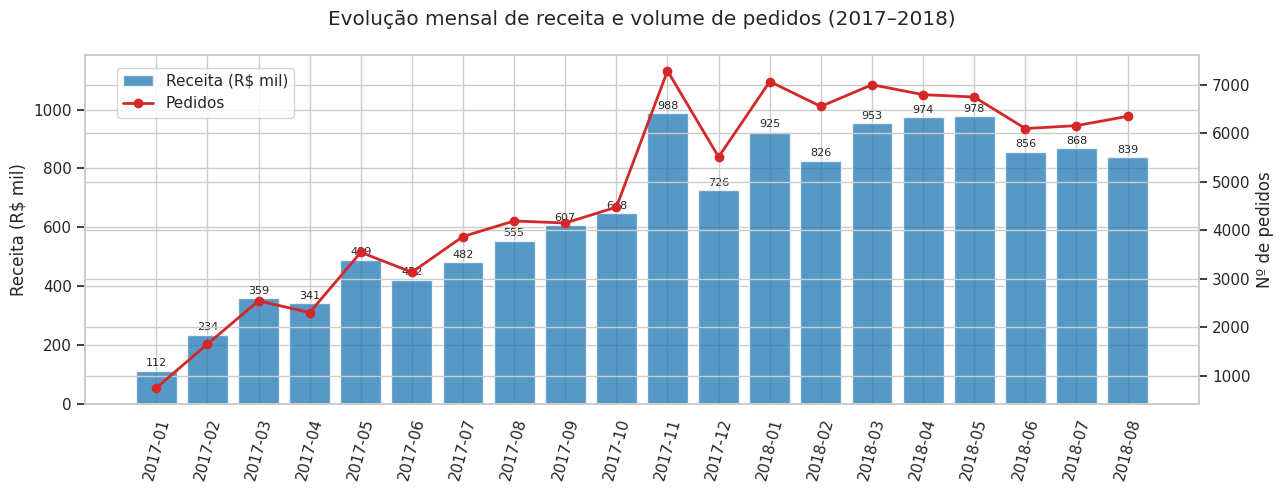

In [ ]:

monthly = (master.groupby("order_month")
    .agg(pedidos=("order_id", "nunique"),
         receita=("price", "sum"),
         itens=("order_item_id", "count"))
    .reset_index())
monthly["ticket_medio"] = monthly["receita"] / monthly["pedidos"]
monthly = monthly[(monthly["order_month"] >= "2017-01") & (monthly["order_month"] <= "2018-08")]

fig, ax1 = plt.subplots(figsize=(13, 5))
bars = ax1.bar(monthly["order_month"], monthly["receita"]/1000, color="#1f77b4", alpha=0.75, label="Receita (R$ mil)")
ax1.set_ylabel("Receita (R$ mil)")
ax1.tick_params(axis='x', rotation=75)

for bar, valor in zip(bars, monthly["receita"]/1000):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
              f"{valor:.0f}", ha="center", fontsize=8)
ax1.set_ylim(0, (monthly["receita"]/1000).max()*1.2)

ax2 = ax1.twinx()
ax2.plot(monthly["order_month"], monthly["pedidos"], color="#d62728", marker="o", linewidth=2, label="Pedidos")
ax2.set_ylabel("Nº de pedidos")

fig.suptitle("Evolução mensal de receita e volume de pedidos (2017–2018)")
fig.legend(loc="upper left", bbox_to_anchor=(0.09, 0.88))
plt.tight_layout()
plt.show()

A receita cresceu de 112 mil reais (janeiro de 2017) para 868 mil reais (julho de 2018), um aumento de 676% no período, acompanhando em paralelo o crescimento no número de pedidos, sinal de que o crescimento veio de mais gente comprando, não de aumento de preço. O pico em novembro de 2017 988 mil reais coincide com a Black Friday.

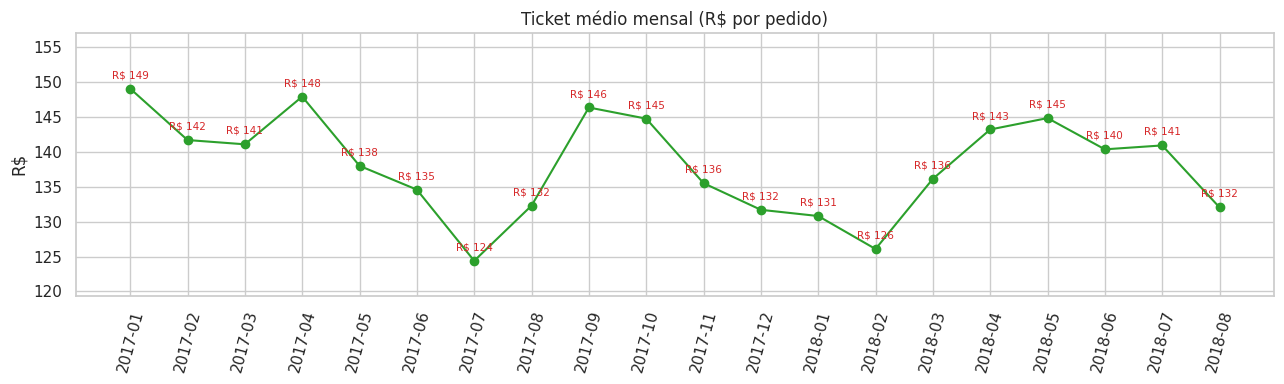

In [ ]:
plt.figure(figsize=(13, 4))
plt.plot(monthly["order_month"], monthly["ticket_medio"], marker="o", color="#2ca02c")
plt.xticks(rotation=75)
plt.title("Ticket médio mensal (R$ por pedido)")
plt.ylabel("R$")

for x, y in zip(monthly["order_month"], monthly["ticket_medio"]):
    plt.text(x, y + 1.5, f"R$ {y:.0f}", ha="center", fontsize=7.5, color="#d62728")

plt.ylim(monthly["ticket_medio"].min()-5, monthly["ticket_medio"].max()+8)
plt.tight_layout()
plt.show()

O ticket médio oscila entre R$ 125 e R$ 149, sem tendência de subida confirma que o crescimento veio de mais pedidos, não de compras mais caras.

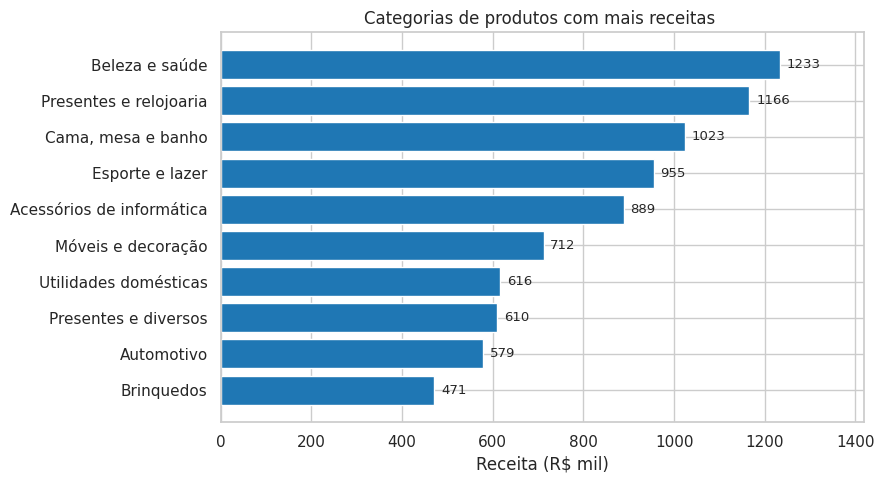

In [ ]:

categoria_pt = {
    "health_beauty": "Beleza e saúde",
    "watches_gifts": "Presentes e relojoaria",
    "bed_bath_table": "Cama, mesa e banho",
    "sports_leisure": "Esporte e lazer",
    "computers_accessories": "Acessórios de informática",
    "furniture_decor": "Móveis e decoração",
    "housewares": "Utilidades domésticas",
    "cool_stuff": "Presentes e diversos",
    "auto": "Automotivo",
    "toys": "Brinquedos",
    "garden_tools": "Jardim e ferramentas",
    "baby": "Bebês",
    "perfumery": "Perfumaria",
    "office_furniture": "Móveis de escritório",
    "electronics": "Eletrônicos",
    "telephony": "Telefonia",
    "fashion_bags_accessories": "Bolsas e acessórios",
    "computers": "Informática",
    "consoles_games": "Consoles e games",
}

top_cat = (master.groupby("product_category_name_english")["price"]
    .sum().sort_values(ascending=False).head(10))

labels = [categoria_pt.get(c, c.replace("_", " ").capitalize()) for c in top_cat.index]

plt.figure(figsize=(9,5))
bars = plt.barh(labels[::-1], (top_cat.values/1000)[::-1], color="#1f77b4")
plt.title("Categorias de produtos com mais receitas ")
plt.xlabel("Receita (R$ mil)")
plt.ylabel("")

for bar, valor in zip(bars, (top_cat.values/1000)[::-1]):
    plt.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
              f"{valor:.0f}", va="center", fontsize=9.5)

plt.xlim(0, (top_cat.values/1000).max()*1.15)
plt.tight_layout()
plt.show()


As 10 categorias líderes respondem por 62,4% da receita, mas de forma bem distribuída: nenhuma domina isoladamente, nem mesmo a líder, beleza e saúde, que representa apenas 9,3% do total.

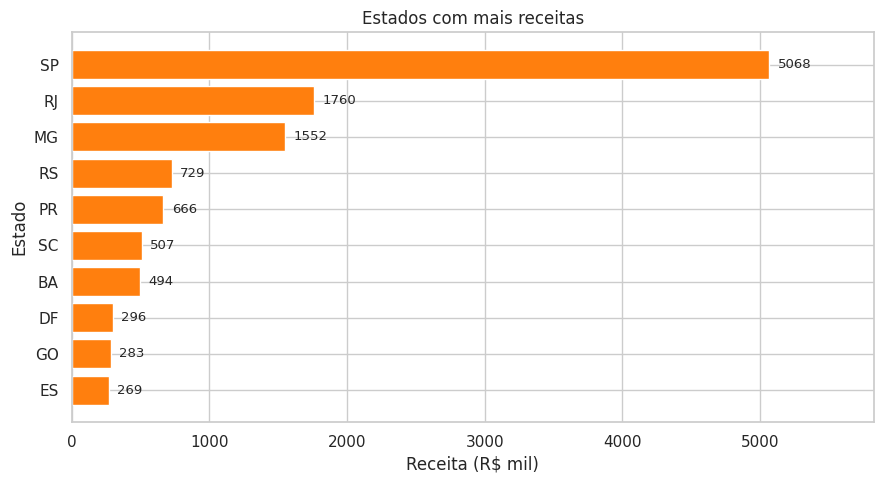

In [ ]:
top_states = (master.groupby("customer_state")["price"]
    .sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(9,5))
bars = plt.barh(top_states.index[::-1], (top_states.values/1000)[::-1], color="#ff7f0e")
plt.title("Estados com mais receitas")
plt.xlabel("Receita (R$ mil)")
plt.ylabel("Estado")

for bar, valor in zip(bars, (top_states.values/1000)[::-1]):
    plt.text(bar.get_width() + 60, bar.get_y() + bar.get_height()/2,
              f"{valor:.0f}", va="center", fontsize=9.5)

plt.xlim(0, (top_states.values/1000).max()*1.15)
plt.tight_layout()
plt.show()

Já a concentração geográfica é bem mais forte: os 10 estados líderes somam 88% da receita, e só três deles (SP, RJ, MG) já respondem por 63% sozinhos. Diferente das categorias, aqui a diversificação é uma prioridade real.

##Leitura executiva

A receita mensal cresceu de R$ 112 mil para R$ 868 mil entre janeiro de 2017 e julho de 2018, um aumento de 676%, acompanhado de perto pelo crescimento no número de pedidos, o que indica que o crescimento veio de mais clientes comprando, não de aumento de preço. O pico em novembro de 2017 coincide com o período da Black Friday.

Esse crescimento, porém, revela dois padrões de concentração bem diferentes. Por categoria de produto, a distribuição é saudável: as 10 categorias líderes somam 62,4% da receita, mas nenhuma domina isoladamente, nem mesmo a líder, beleza e saúde, que representa apenas 9,3% do total. Já por estado, a concentração é bem mais acentuada: os 10 estados líderes respondem por quase 88% da receita, e apenas três deles, São Paulo, Rio de Janeiro e Minas Gerais, já concentram 63% sozinhos.

##Recomendação

Como o portfólio de produtos já está bem distribuído, o esforço de diversificação deve priorizar a dimensão geográfica, não a de categoria. Vale investir em ações comerciais direcionadas a estados fora do eixo Sul-Sudeste, como campanhas regionais, parcerias locais ou frete facilitado nessas regiões, para reduzir a dependência de São Paulo, Rio de Janeiro e Minas Gerais.

## 5. Logística e SLA

Esta seção analisa o tempo de entrega, a frequência de atrasos, e o impacto disso na satisfação do cliente.

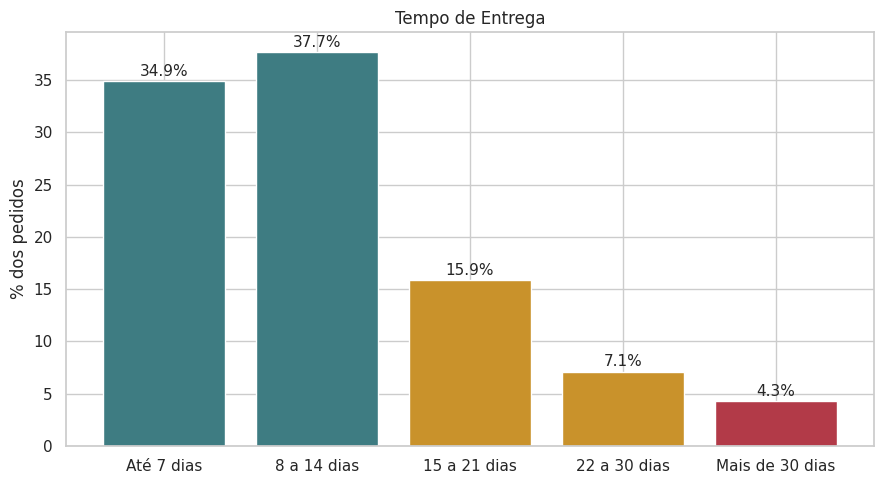

In [ ]:
lt = delivered["lead_time_days"].dropna()

faixas = pd.cut(lt, bins=[-1,7,14,21,30,999],
    labels=["Até 7 dias", "8 a 14 dias", "15 a 21 dias", "22 a 30 dias", "Mais de 30 dias"])
distribuicao = (faixas.value_counts(normalize=True).sort_index() * 100).round(1)

cores = ["#3E7C82", "#3E7C82", "#C9922B", "#C9922B", "#B23A48"]

plt.figure(figsize=(9,5))
bars = plt.bar(distribuicao.index, distribuicao.values, color=cores)
plt.ylabel("% dos pedidos")
plt.title("Tempo de Entrega")


for bar, valor in zip(bars, distribuicao.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f"{valor}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()




Quase 73% dos pedidos chegam em até 2 semanas, um desempenho consistente. Só uma minoria pequena (4,3%) ultrapassa um mês.

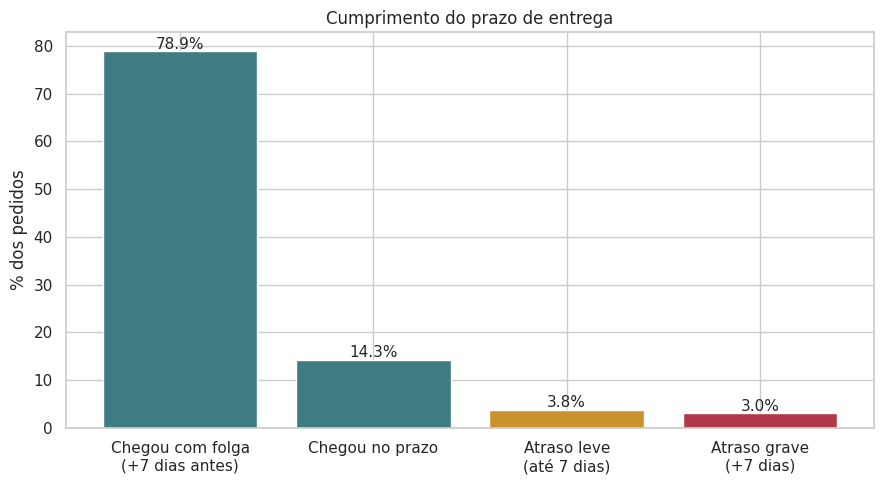

In [ ]:
d = delivered["delay_days"].dropna()

faixas = pd.cut(d, bins=[-999,-7,0,7,999],
    labels=["Chegou com folga\n(+7 dias antes)", "Chegou no prazo", "Atraso leve\n(até 7 dias)", "Atraso grave\n(+7 dias)"])
distribuicao = (faixas.value_counts(normalize=True).sort_index() * 100).round(1)

cores = ["#3E7C82", "#3E7C82", "#C9922B", "#B23A48"]

plt.figure(figsize=(9,5))
bars = plt.bar(distribuicao.index, distribuicao.values, color=cores)
plt.ylabel("% dos pedidos")
plt.title("Cumprimento do prazo de entrega")

for bar, valor in zip(bars, distribuicao.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f"{valor}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()




93,2% dos pedidos cumprem ou superam o prazo prometido. O atraso, quando ocorre, é minoria: apenas 3% chegam com atraso grave.

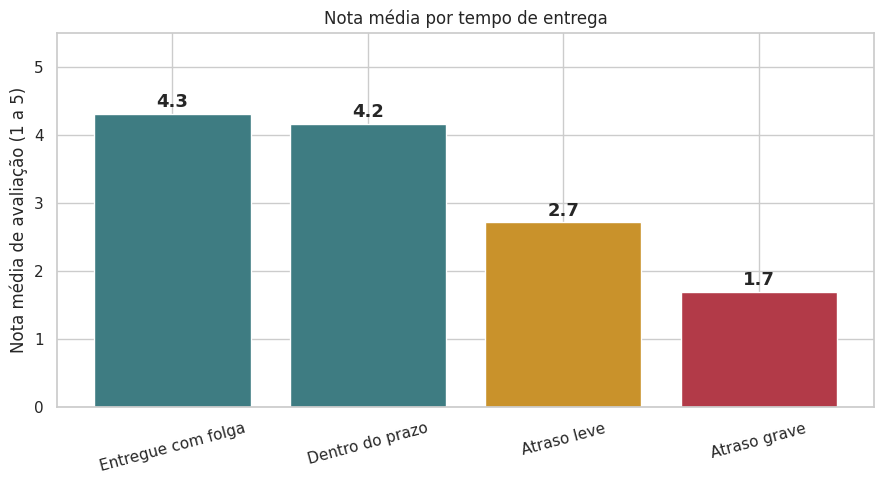

In [ ]:
dr = (delivered[["order_id","delay_days"]]
    .merge(rev_agg[["order_id","review_score"]], on="order_id", how="inner"))

dr["faixa"] = pd.cut(
    dr["delay_days"],
    bins=[-999,-7,0,7,999],
    labels=["Entregue com folga","Dentro do prazo","Atraso leve","Atraso grave"]
)

nota_media = dr.groupby("faixa", observed=False)["review_score"].mean()

cores = ["#3E7C82","#3E7C82","#C9922B","#B23A48"]

plt.figure(figsize=(9,5))
bars = plt.bar(nota_media.index, nota_media.values, color=cores)
plt.ylabel("Nota média de avaliação (1 a 5)")
plt.title("Nota média por tempo de entrega")
plt.ylim(0,5.5)
plt.xticks(rotation=15)

for bar, valor in zip(bars, nota_media.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{valor:.1f}", ha="center", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


A nota cai pouco entre "com folga" e "no prazo" (4,3 e 4,2), mas despenca no atraso grave (1,7) — menos da metade da nota de quem recebeu no prazo.

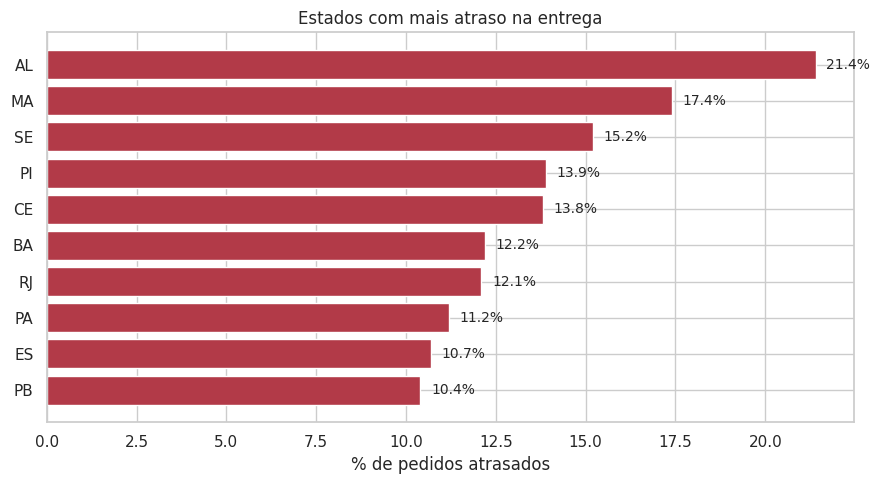

In [ ]:
state_perf = (delivered.merge(customers, on="customer_id")
    .groupby("customer_state")
    .agg(pct_atraso=("atrasado", "mean"), pedidos=("order_id", "nunique")))


state_perf = state_perf[state_perf["pedidos"] >= 200]
state_perf["pct_atraso"] = (state_perf["pct_atraso"] * 100).round(1)
top10_atraso = state_perf.sort_values("pct_atraso", ascending=False).head(10)

media_nacional = delivered["atrasado"].mean() * 100
cores = ["#B23A48" if v > media_nacional else "#C9922B" for v in top10_atraso["pct_atraso"]]

plt.figure(figsize=(9,5))
bars = plt.barh(top10_atraso.index[::-1], top10_atraso["pct_atraso"].values[::-1], color=cores[::-1])

plt.xlabel("% de pedidos atrasados")
plt.title("Estados com mais atraso na entrega")


for bar, valor in zip(bars, top10_atraso["pct_atraso"].values[::-1]):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
              f"{valor}%", va="center", fontsize=10)

plt.tight_layout()
plt.show()


Alagoas lidera com 21,4% de atraso, mais de 3x a média nacional (6,8%). A lista é dominada por estados do Norte e Nordeste, com uma única exceção: o RJ, que chama atenção por ser um mercado grande.

##Leitura executiva

O desempenho logístico é sólido: 93,2% dos pedidos cumprem ou superam o prazo, e o atraso grave afeta só 3%. Mas seu impacto é desproporcional: a nota despenca de 4,3 para 1,7 quando o atraso é grave. Alagoas lidera o atraso (21,4%, mais de 3x a média nacional), numa lista dominada por Norte e Nordeste, com uma exceção do Rio de Janeiro

##Recomendação

Nos estados do Nordeste, avaliar parceria com transportadoras regionais e revisar se o prazo prometido é realista para a região. No Rio de Janeiro, auditar o desempenho por transportadora, já que o alto volume do estado faz qualquer melhoria ali ter mais impacto na taxa nacional do que ajustes no Nordeste.

## 6. Satisfação do Cliente

Esta seção analisa a distribuição das notas de avaliação, os fatores que mais influenciam a satisfação do cliente, e as categorias com maior risco de insatisfação.

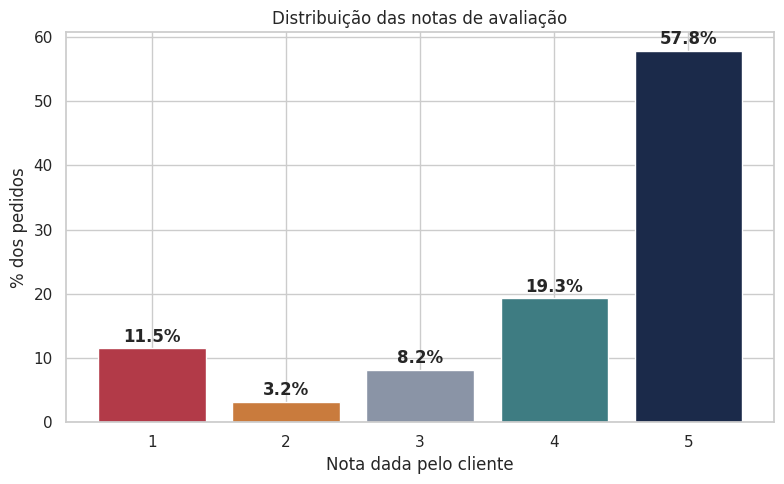

In [ ]:
distribuicao = (reviews["review_score"].value_counts(normalize=True).sort_index() * 100).round(1)
cores = ["#B23A48", "#C97B3D", "#8A94A6", "#3E7C82", "#1B2A4A"]

plt.figure(figsize=(8,5))
bars = plt.bar(distribuicao.index.astype(str), distribuicao.values, color=cores)
plt.xlabel("Nota dada pelo cliente")
plt.ylabel("% dos pedidos")
plt.title("Distribuição das notas de avaliação")

for bar, valor in zip(bars, distribuicao.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f"{valor}%", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()



57,8% dos pedidos recebem nota máxima, mas 11,5% recebem a nota mínima, quase o dobro de quem dá nota 2. A insatisfação, quando acontece, tende a ser severa, não moderada.

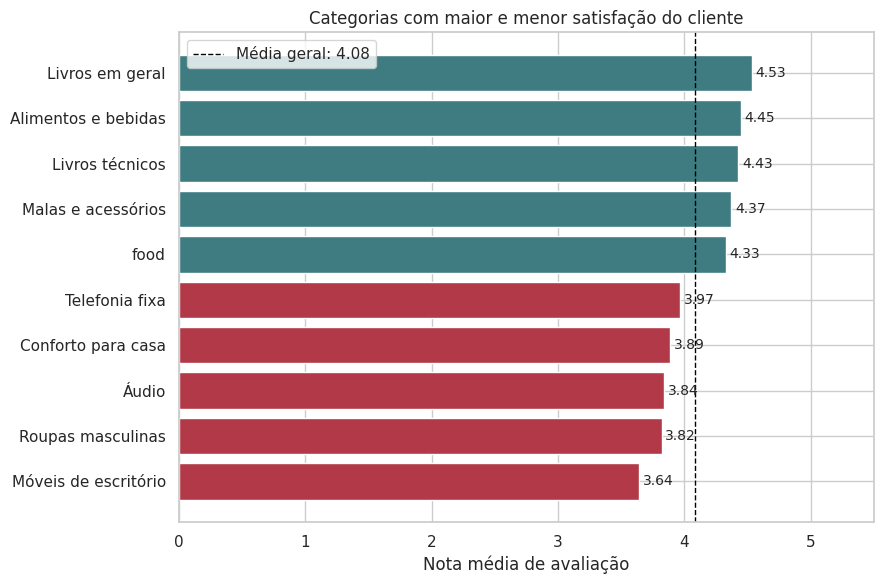

In [ ]:
categoria_pt = {
    "office_furniture": "Móveis de escritório",
    "fixed_telephony": "Telefonia fixa",
    "fashion_male_clothing": "Roupas masculinas",
    "audio": "Áudio",
    "home_confort": "Conforto para casa",
    "fashion_shoes": "Calçados",
    "luggage_accessories": "Malas e acessórios",
    "food_drink": "Alimentos e bebidas",
    "books_technical": "Livros técnicos",
    "books_general_interest": "Livros em geral",
}
cat_review = (master.dropna(subset=["review_score"])
    .groupby(["order_id", "product_category_name_english"])
    .agg(review_score=("review_score","first"))
    .reset_index()
    .groupby("product_category_name_english")
    .agg(
        nota_media=("review_score","mean"),
        pedidos=("order_id","nunique")
    )
    .query("pedidos >= 100")
    .sort_values("nota_media"))

piores5 = cat_review.head(5)
melhores5 = cat_review.tail(5)

comparacao = pd.concat([piores5, melhores5])
comparacao.index = [categoria_pt.get(c, c) for c in comparacao.index]

cores = ["#B23A48"]*5 + ["#3E7C82"]*5

plt.figure(figsize=(9, 6))
bars = plt.barh(comparacao.index, comparacao["nota_media"], color=cores)

media_geral = master["review_score"].mean()
plt.axvline(media_geral, color="black", linestyle="--", linewidth=1,
            label=f"Média geral: {media_geral:.2f}")

plt.xlabel("Nota média de avaliação")
plt.title("Categorias com maior e menor satisfação do cliente")
plt.legend()

for bar, valor in zip(bars, comparacao["nota_media"]):
    plt.text(bar.get_width()+0.03, bar.get_y()+bar.get_height()/2,
             f"{valor:.2f}", va="center", fontsize=10)

plt.xlim(0, 5.5)
plt.tight_layout()
plt.show()



As categorias com maiores avaliações incluem produtos relativamente simples e padronizados.

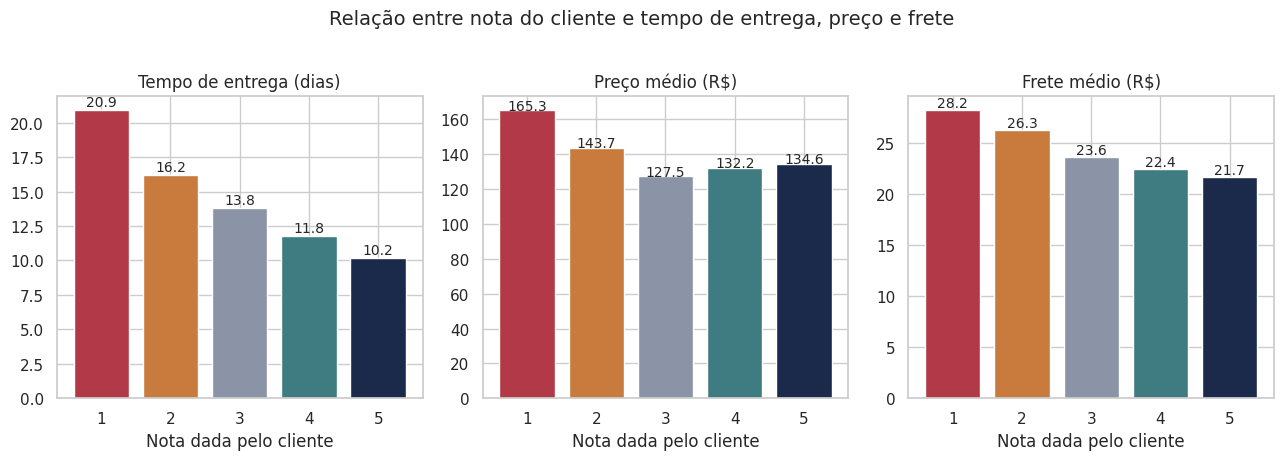

In [ ]:
valor_pedido = (items.groupby("order_id")
    .agg(preco=("price","sum"), frete=("freight_value","sum"))
    .reset_index())

dr = (delivered[["order_id","lead_time_days"]]
    .merge(rev_agg[["order_id","review_score"]], on="order_id", how="inner")
    .merge(valor_pedido, on="order_id", how="left"))

dr["nota"] = dr["review_score"].round().astype(int)

comparacao = dr.groupby("nota").agg(
    tempo_entrega=("lead_time_days","mean"),
    preco=("preco","mean"),
    frete=("frete","mean")
).round(1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

titulos = ["Tempo de entrega (dias)", "Preço médio (R$)", "Frete médio (R$)"]
colunas = ["tempo_entrega", "preco", "frete"]
cores_nota = ["#B23A48", "#C97B3D", "#8A94A6", "#3E7C82", "#1B2A4A"]

for ax, col, titulo in zip(axes, colunas, titulos):
    bars = ax.bar(comparacao.index.astype(str), comparacao[col], color=cores_nota)
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel("Nota dada pelo cliente")
    for bar, valor in zip(bars, comparacao[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{valor}", ha="center", fontsize=10)

plt.suptitle("Relação entre nota do cliente e tempo de entrega, preço e frete", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Entre os três fatores analisados, apenas o tempo de entrega varia de forma consistente com a nota, caindo da media de 20 dias (nota 1) para media de 10 dias (nota 5). Preço médio e frete médio permanecem praticamente estáveis entre os grupos, sem relação clara com a satisfação. Isso reforça que o cliente não está insatisfeito por conta do preço e sim pelo tempo de espera

##Leitura executiva

A maioria dos clientes está satisfeito 57,8% dos pedidos recebem nota máxima. Mas a insatisfação, quando ocorre, é intensa: 11,5% recebem a nota mínima, quase o dobro da proporção que recebe nota 2, o que mostra que o cliente raramente fica no meio termo, ele costuma dar nota máxima ou nota mínima.

O tempo é a principal causa para as baixas avaliações, quem dá nota 1 esperou em média 20,9 dias pela entrega, contra 10,2 dias de quem dá nota 5. Preço e frete não seguem esse padrão, o que indica que o fator decisivo não é o preço do produto mas sim o tempo de espera.

Há também um padrão por tipo de produto. Categorias simples e padronizadas, como livros e alimentos, têm as melhores notas. Categorias mais complexas, como móveis e telefonia, têm as piores, com destaque negativo para móveis de escritório, com nota 3,51. Isso sugere uma segunda causa de insatisfação além do prazo: a complexidade ou a divergência entre expectativa e produto recebido.

##Recomendação

Priorizar prazo de entrega como a principal fator de satisfação. Para as categorias de pior desempenho, revisar comunicação e expectativa criada na página do produto, e conversar com os vendedores dessas categorias específicas.

## 7. Comportamento e Pagamentos

Esta seção analisa a forma de pagamento dos clientes, o perfil de valor por cliente, e a taxa de recompra ao longo do tempo.

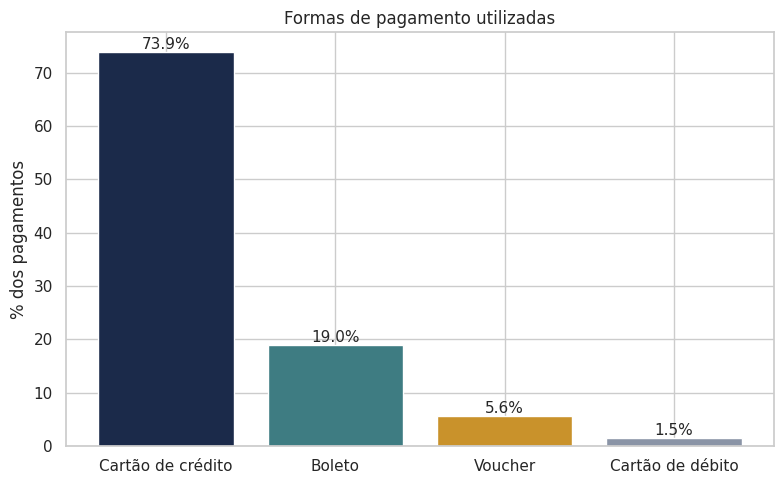

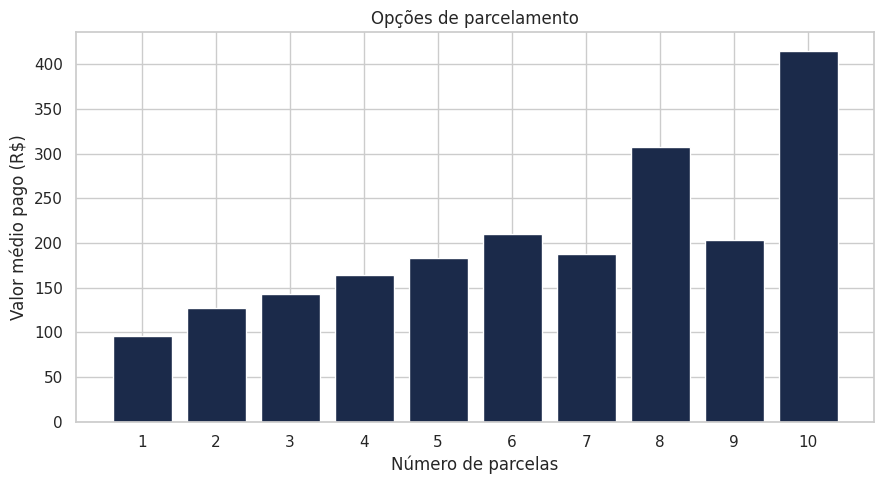

In [ ]:
pagamento_pt = {"credit_card": "Cartão de crédito", "boleto": "Boleto",
                 "voucher": "Voucher", "debit_card": "Cartão de débito", "not_defined": "Não definido"}

dist_pagamento = (payments["payment_type"].value_counts(normalize=True) * 100).round(1)
dist_pagamento.index = [pagamento_pt.get(p, p) for p in dist_pagamento.index]
dist_pagamento = dist_pagamento[dist_pagamento.index != "Não definido"]

plt.figure(figsize=(8, 5))
bars = plt.bar(dist_pagamento.index, dist_pagamento.values, color=["#1B2A4A","#3E7C82","#C9922B","#8A94A6"])
plt.ylabel("% dos pagamentos")
plt.title("Formas de pagamento utilizadas")
for bar, valor in zip(bars, dist_pagamento.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f"{valor}%", ha="center", fontsize=11)
plt.tight_layout()
plt.show()


cartao = payments[payments["payment_type"]=="credit_card"].copy()
valor_por_parcela = cartao.groupby("payment_installments")["payment_value"].mean()
valor_por_parcela = valor_por_parcela[(valor_por_parcela.index>=1) & (valor_por_parcela.index<=10)]

plt.figure(figsize=(9, 5))
plt.bar(valor_por_parcela.index.astype(str), valor_por_parcela.values, color="#1B2A4A")
plt.xlabel("Número de parcelas")
plt.ylabel("Valor médio pago (R$)")
plt.title("Opções de parcelamento")
plt.tight_layout()
plt.show()


Cartão de crédito domina, usado em 73,9% dos pagamentos, seguido por boleto (19%), enquanto voucher e débito têm participação pequena. Quanto mais parcelas, maior o valor da compra de 100 reais em média no pagamento à vista até mais de 400 reais em compras parceladas em 10x, o que abre espaço para parcelamento como estratégia de aumento para incentivar o cliente a gastar mais por pedido

In [ ]:
orders_cust = orders.merge(customers[["customer_id","customer_unique_id"]], on="customer_id")
pay_by_order = payments.groupby("order_id", as_index=False)["payment_value"].sum()
rfm_base = (orders_cust[orders_cust.order_status=="delivered"]
    .merge(pay_by_order, on="order_id", how="left"))

ref_date = rfm_base["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (rfm_base.groupby("customer_unique_id")
    .agg(recencia_dias=("order_purchase_timestamp", lambda x: (ref_date - x.max()).days),
         frequencia=("order_id", "nunique"),
         valor_total=("payment_value", "sum"))
    .reset_index())

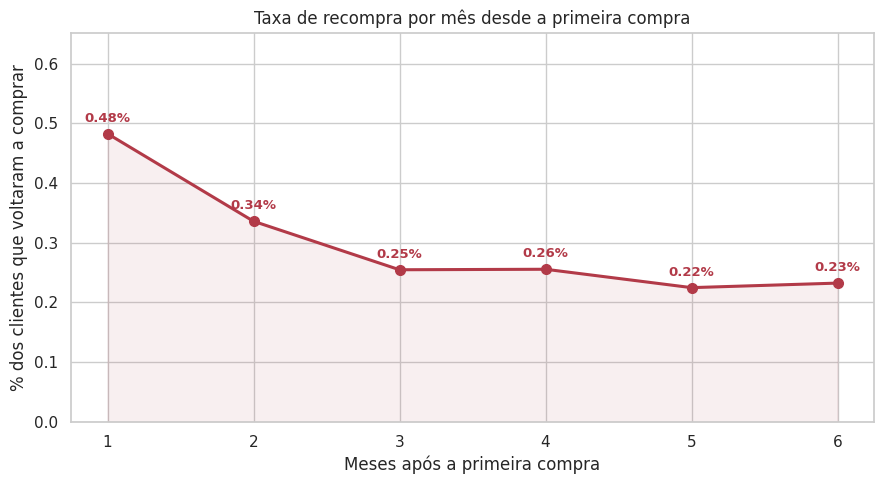

In [ ]:
oc = orders_cust[orders_cust["order_status"]=="delivered"].copy()
oc["mes_compra"] = oc["order_purchase_timestamp"].dt.to_period("M")
primeira = (oc.groupby("customer_unique_id")["mes_compra"]
    .min()
    .rename("coorte"))

oc = oc.merge(primeira, on="customer_unique_id", how="left")
oc["meses_desde"] = (oc["mes_compra"]-oc["coorte"]).apply(lambda x: x.n)
tamanho_coorte = (oc.groupby("coorte")["customer_unique_id"]
    .nunique())

ativos = (oc.groupby(["coorte","meses_desde"])["customer_unique_id"]
    .nunique()
    .unstack(fill_value=0))

ultimo_mes = oc["mes_compra"].max()
retencao = {}
for mes in range(1,7):
    coortes_elegiveis = tamanho_coorte.index[
        (tamanho_coorte.index+mes)<=ultimo_mes]

    if len(coortes_elegiveis)==0:
        break

    clientes_retidos = ativos.loc[
        ativos.index.isin(coortes_elegiveis),mes
    ].sum()

    clientes_elegiveis = tamanho_coorte.loc[
        coortes_elegiveis
    ].sum()

    retencao[mes] = clientes_retidos/clientes_elegiveis*100

retencao = pd.Series(retencao)
plt.figure(figsize=(9,5))

plt.plot(
    retencao.index.astype(str),
    retencao.values,
    marker="o",
    color="#B23A48",
    linewidth=2.2,
    markersize=7
)

plt.fill_between(
    retencao.index.astype(str),
    retencao.values,
    alpha=0.08,
    color="#B23A48"
)
plt.xlabel("Meses após a primeira compra")
plt.ylabel("% dos clientes que voltaram a comprar")
plt.title("Taxa de recompra por mês desde a primeira compra")
for x,y in zip(retencao.index.astype(str),retencao.values):
    plt.text(
        x,y+0.02,
        f"{y:.2f}%",
        ha="center",
        fontsize=9.5,
        color="#B23A48",
        fontweight="bold"
    )

plt.ylim(0,retencao.max()*1.35)
plt.tight_layout()
plt.show()

Apenas 0,48% dos clientes voltam a comprar já no primeiro mês, e a taxa só cai depois disso. A base de clientes é majoritariamente de passagem.

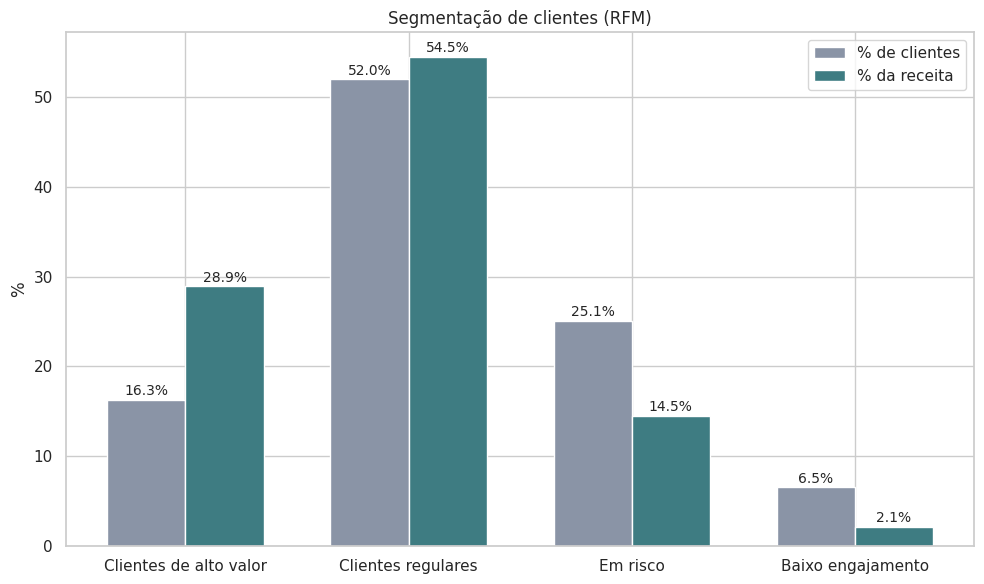

In [ ]:
rfm["R_score"] = pd.qcut(rfm["recencia_dias"], 4, labels=[4,3,2,1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequencia"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["valor_total"], 4, labels=[1,2,3,4]).astype(int)
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def segmenta(row):
    if row["RFM_score"] >= 10:
        return "Clientes de alto valor"
    elif row["RFM_score"] >= 7:
        return "Clientes regulares"
    elif row["RFM_score"] >= 5:
        return "Em risco"
    else:
        return "Baixo engajamento"

rfm["segmento"] = rfm.apply(segmenta, axis=1)

seg_summary = (rfm.groupby("segmento")
    .agg(clientes=("customer_unique_id", "count"), valor_total=("valor_total", "sum"))
    .sort_values("valor_total", ascending=False))
seg_summary["%_clientes"] = (seg_summary["clientes"]/len(rfm)*100).round(1)
seg_summary["%_receita"] = (seg_summary["valor_total"]/rfm["valor_total"].sum()*100).round(1)


ordem = ["Clientes de alto valor", "Clientes regulares", "Em risco", "Baixo engajamento"]
seg_plot = seg_summary.reindex(ordem)

x = np.arange(len(seg_plot))
largura = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
barras1 = ax.bar(x - largura/2, seg_plot["%_clientes"], largura, label="% de clientes", color="#8A94A6")
barras2 = ax.bar(x + largura/2, seg_plot["%_receita"], largura, label="% da receita", color="#3E7C82")

ax.set_xticks(x)
ax.set_xticklabels(seg_plot.index)
ax.set_ylabel("%")
ax.set_title("Segmentação de clientes (RFM)")
ax.legend()


for barras in [barras1, barras2]:
    for bar in barras:
        altura = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, altura+0.5, f"{altura}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()



“Clientes regulares” representam a maioria da base de clientes (52%) e são responsáveis por uma participação proporcional na receita (54,5%). Esse equilíbrio demonstra a relevância desse grupo para a estabilidade e a sustentação do negócio. “Clientes de Alto Valor” representam 16,3% da base de clientes, mas são responsáveis por 28,9% da receita. Essa diferença evidencia a elevada contribuição desse grupo para o faturamento, tornando importante monitorar seu comportamento e desenvolver estratégias de retenção para preservar seu valor para o negócio.

##Leitura Executiva

O cartão de crédito representa 74% dos pagamentos. Além disso, compras com mais parcelas tendem a ter um valor maior, passando de 96 reais à vista para mais de 400 reais em 10x, mostrando que o parcelamento pode ajudar a aumentar o ticket médio.

No RFM, apenas 16% dos clientes são de alto valor, mas eles geram quase 29% da receita. Já os clientes “Em risco” representam 25% da base e 14,5% da receita, mostrando uma oportunidade de recuperação.

O principal problema é a retenção: menos de 1% dos clientes volta a comprar no mês seguinte. Ou seja, a empresa depende muito de novos clientes.

##Recomendação

Oferecer condições de parcelamento mais atrativas é uma forma direta de aumentar o valor das compras, já que o cartão de crédito domina os pagamentos. Mas o ponto mais urgente é a retenção: com a empresa dependendo quase inteiramente de clientes novos, vale estruturar um programa de relacionamento com dois focos. Primeiro, reter os clientes de alto valor, que já geram quase 29% da receita com apenas 16% da base. Segundo, reativar os clientes em risco antes que se tornem inativos, com ações como cupons e comunicação segmentada.

## 8. Oportunidade e recomendação


Esta seção análisa onde o frete pode ser otimizado, quais categorias têm potencial de cross-sell, e quais vendedores devem ser priorizados por combinarem alta satisfação e entrega rápida.

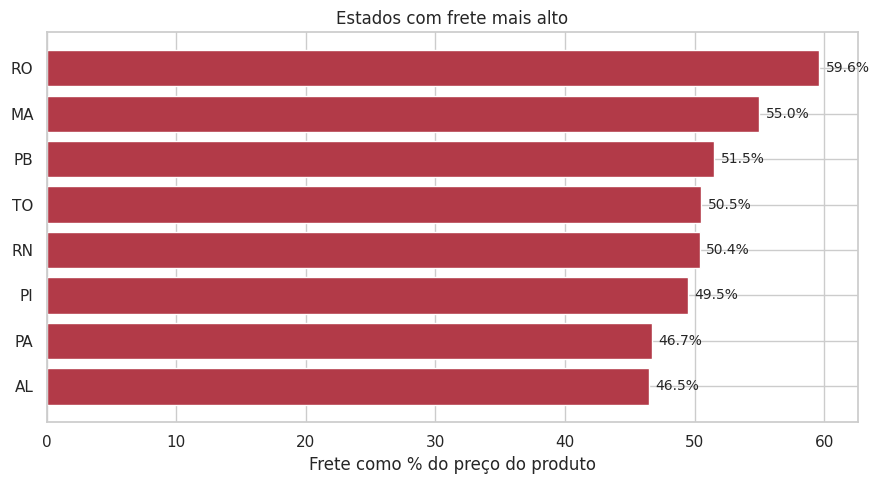

In [ ]:
master["frete_pct"] = master["freight_value"] / master["price"].replace(0, np.nan)
frete_estado = (master.groupby("customer_state")
    .agg(frete_pct_medio=("frete_pct","mean"), pedidos=("order_id","nunique")))
frete_estado = frete_estado[frete_estado["pedidos"]>=200].sort_values("frete_pct_medio", ascending=False).head(8)
frete_estado["frete_pct_medio"] = (frete_estado["frete_pct_medio"]*100).round(1)

plt.figure(figsize=(9,5))
bars = plt.barh(frete_estado.index[::-1], frete_estado["frete_pct_medio"][::-1], color="#B23A48")
plt.xlabel("Frete como % do preço do produto")
plt.title("Estados com frete mais alto")
for bar, valor in zip(bars, frete_estado["frete_pct_medio"][::-1]):
    plt.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f"{valor}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()



Em Rondônia, o frete chega a 59,6% do valor do produto, quase R$ 60 de frete para cada R$ 100 de produto. Todos os 8 estados dessa lista são do Norte ou Nordeste, nenhum do Sul, Sudeste ou Centro-Oeste aparece, o que confirma que o problema é estrutural: quanto mais distante do centro de distribuição concentrado no Sudeste, maior o peso do frete no preço final.

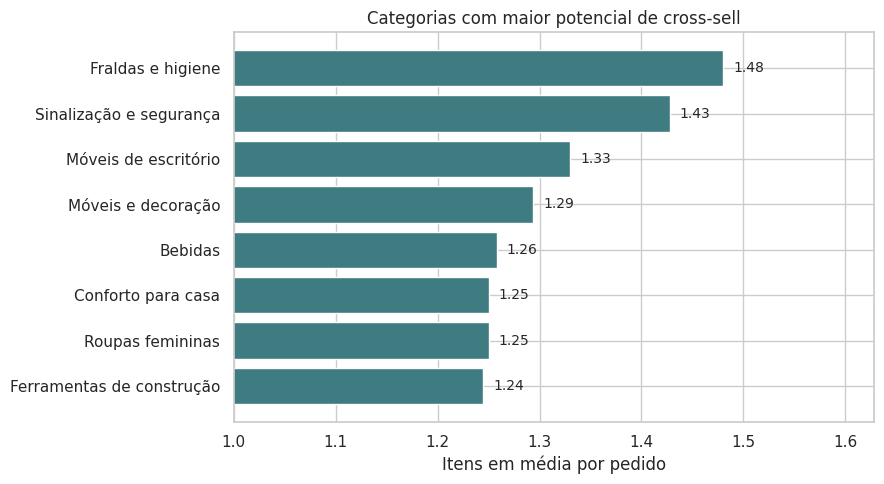

In [ ]:
categoria_pt = {
    "diapers_and_hygiene": "Fraldas e higiene",
    "signaling_and_security": "Sinalização e segurança",
    "office_furniture": "Móveis de escritório",
    "furniture_decor": "Móveis e decoração",
    "drinks": "Bebidas",
    "home_comfort_2": "Conforto para casa",
    "fashio_female_clothing": "Roupas femininas",
    "construction_tools_construction": "Ferramentas de construção",
}

itens_por_pedido = (master.groupby("product_category_name_english")["order_id"]
                     .apply(lambda x: len(x)/x.nunique()).sort_values(ascending=False).head(8))

labels = [categoria_pt.get(c, c.replace("_", " ").capitalize()) for c in itens_por_pedido.index]

plt.figure(figsize=(9,5))
bars = plt.barh(labels[::-1], itens_por_pedido.values[::-1], color="#3E7C82")
plt.xlabel("Itens em média por pedido")
plt.title("Categorias com maior potencial de cross-sell")

for bar, valor in zip(bars, itens_por_pedido.values[::-1]):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"{valor:.2f}", va="center", fontsize=10)

plt.xlim(1, itens_por_pedido.max()*1.1)
plt.tight_layout()
plt.show()



Fraldas e higiene lidera com 1,48 itens por pedido em média, o cliente já compra mais de um item nessa categoria naturalmente. Esse comportamento espontâneo é uma oportunidade de negócio: ofertas de kit ou combo nessas categorias tendem a converter melhor do que em categorias onde o cliente já compra só um item por vez.

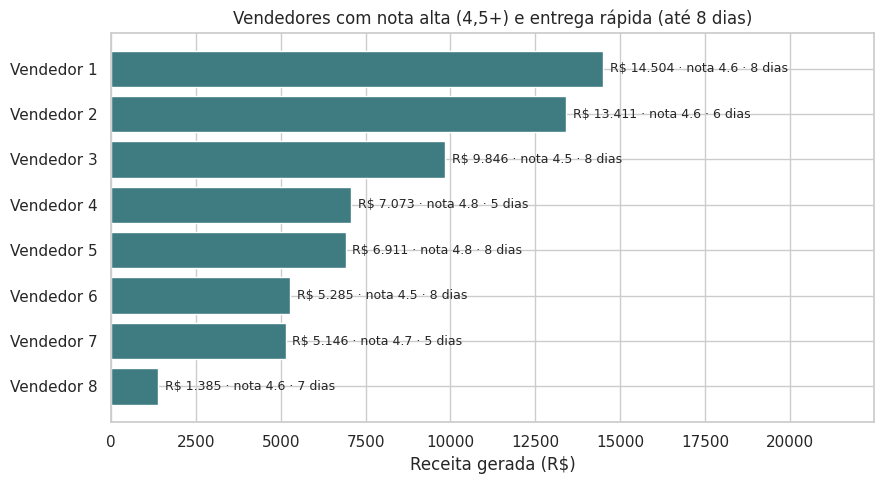

In [ ]:
seller_pedido = (master.dropna(subset=["seller_id"])
    .groupby(["seller_id","order_id"])
    .agg(
        nota_media=("review_score","first"),
        lead_time_medio=("lead_time_days","first"),
        receita=("price","sum")
    )
    .reset_index())
seller_perf = seller_pedido.groupby("seller_id").agg(
    nota_media=("nota_media","mean"),
    lead_time_medio=("lead_time_medio","mean"),
    pedidos=("order_id","nunique"),
    receita=("receita","sum")
).query("pedidos>=50")

candidatos = seller_perf[
    (seller_perf["nota_media"]>=4.5) &
    (seller_perf["lead_time_medio"]<=8)
]
candidatos = candidatos.sort_values(
    "receita", ascending=False
).reset_index(drop=True)

candidatos.index = [
    f"Vendedor {i+1}" for i in range(len(candidatos))
]
plt.figure(figsize=(9,5))
bars = plt.barh(
    candidatos.index[::-1],
    candidatos["receita"][::-1],
    color="#3E7C82"
)

plt.xlabel("Receita gerada (R$)")
plt.title("Vendedores com nota alta (4,5+) e entrega rápida (até 8 dias)")

for bar, (_, row) in zip(
    bars,
    candidatos[::-1].iterrows()
):
    texto = (
        f"R$ {row['receita']:,.0f} · "
        f"nota {row['nota_media']:.1f} · "
        f"{row['lead_time_medio']:.0f} dias"
    ).replace(",", ".")

    plt.text(
        bar.get_width()+200,
        bar.get_y()+bar.get_height()/2,
        texto,
        va="center",
        fontsize=9
    )
plt.xlim(0,candidatos["receita"].max()*1.55)
plt.tight_layout()
plt.show()

8 vendedores já entregam nota alta (4,5+) e entrega rápida (até 8 dias), somando R$ 63,5 mil em receita, todos candidatos a parceria estendida. Priorizar o Vendedor 1 e o Vendedor 2, que têm maior volume.

##Leitura executiva

O frete pesa muito mais em algumas regiões do que em outras. Em Rondônia, chega a 59,6% do valor do produto, quase 60 reais de frete para cada 100 reais de produto. Todos os 8 estados com frete mais caro são do Norte ou Nordeste, confirmando que o problema é estrutural e ligado à distância dos centros de distribuição no Sudeste.

Algumas categorias já demonstram potencial de venda casada. Fraldas e higiene, e sinalização e segurança lideram, com o cliente comprando naturalmente mais de um item por pedido, um comportamento espontâneo que facilita ofertas de kit ou combo, sem depender de desconto agressivo.

Identificamos também 8 vendedores que já combinam nota alta (4,5 ou mais) e entrega rápida (até 8 dias), somando R$ 63,5 mil em receita. Todos são candidatos válidos a um programa de parceria estendida, com os de maior volume, Vendedor 1 e Vendedor 2, indicados como prioridade de ação por gerarem impacto mais rápido.

##Recomendação

Negociar frete regionalizado ou parcerias logísticas locais nos estados do Norte e Nordeste, reduzindo uma barreira concreta à compra nessas regiões. Criar ofertas de kit ou combo nas categorias que já têm comportamento de compra múltipla estabelecido. E formalizar parceria estendida com os vendedores de melhor desempenho combinado, começando pelos de maior volume.

## 9. Síntese executiva e próximos passos

O negócio analisado demonstra crescimento comercial real e consistente. A receita cresceu 676% entre janeiro de 2017 e julho de 2018, puxada por mais pedidos, não por aumento de preço. Esse crescimento, porém, ainda depende de fatores que podem ser fortalecidos com ações relativamente diretas.

A concentração de receita revela dois padrões distintos. Por categoria de produto, a distribuição é saudável, com as 10 categorias líderes somando 62,4% da receita, mas nenhuma passando de 9,3% isoladamente. Por estado, a concentração é bem mais forte: os 10 estados líderes somam 88%, e só três, São Paulo, Rio de Janeiro e Minas Gerais, já respondem por 63%. Diversificação geográfica é mais urgente do que diversificação de portfólio.

Na logística, o desempenho é sólido, com 93,2% dos pedidos cumprindo ou superando o prazo, mas o impacto do atraso na satisfação é desproporcional: a nota cai de 4,1 para 1,7 quando o atraso se torna grave. Alagoas lidera o atraso entre os estados, numa lista dominada por Norte e Nordeste, com uma exceção relevante, o Rio de Janeiro, que tem alto volume e merece investigação separada.

Na satisfação do cliente, o tempo de entrega é o principal fator para as baixas avaliações, muito mais determinante do que preço ou frete. Categorias mais complexas, como móveis e telefonia, também têm pior desempenho, sugerindo uma segunda causa de insatisfação ligada à natureza do produto.

No comportamento do cliente, o cartão de crédito domina os pagamentos, e o parcelamento pode ser explorado como forma de aumentar o valor das compras. Mas o achado mais crítico do relatório está aqui: apenas 0,48% dos clientes volta a comprar já no primeiro mês, o que mostra que o crescimento hoje depende quase inteiramente de clientes novos, um modelo caro de sustentar no longo prazo.

As principais ações recomendadas são:

Estruturar um programa de retenção de clientes, com foco em reter o grupo de alto valor e reativar o grupo em risco. Investir em logística priorizando o Rio de Janeiro pelo volume de pedidos, além dos estados do Nordeste com maior taxa de atraso. Diversificar geograficamente a base de clientes, reduzindo a dependência de São Paulo, Rio de Janeiro e Minas Gerais. Tratar prazo de entrega como a principal alavanca de satisfação do cliente, acima de preço ou frete. E formalizar as oportunidades já identificadas: frete regionalizado, ofertas de combo nas categorias com compra múltipla, e parceria estendida com os vendedores de melhor desempenho.

Como próximos passos, recomenda-se validar esses achados com dados mais recentes do comércio eletrônico brasileiro, já que a base analisada cobre apenas até 2018.